# 🎓 Student Performance — EDA, Preprocessing & Feature Engineering

---

## 🎯 এই Dataset দিয়ে কী Achieve করতে চাই?

এটি একটি **Student Performance** dataset। প্রতিটি row একজন student।  
Dataset-এ student-এর বয়স, লিঙ্গ, সাপ্তাহিক পড়ার সময়, অনুপস্থিতি, পারিবারিক সহায়তা সহ বিভিন্ন তথ্য আছে।

**Target column:** `GradeClass` — student কোন grade পেয়েছে:
- 0 → A (GPA ≥ 3.5)
- 1 → B (3.0 ≤ GPA < 3.5)
- 2 → C (2.5 ≤ GPA < 3.0)
- 3 → D (2.0 ≤ GPA < 2.5)
- 4 → F (GPA < 2.0)

**মূল প্রশ্ন:** একজন student-এর absences, study time, parental support ইত্যাদি দেখে কি আগে থেকে predict করা যাবে সে কোন grade পাবে?

---

## ✅ EDA থেকে কী Achieve করব?

| লক্ষ্য | কারণ |
|---|---|
| Dataset-এর গঠন বোঝা | কোন column কী ধরনের data রাখে |
| Missing values খোঁজা | Data clean কিনা |
| GradeClass-এর distribution দেখা | Class imbalance আছে কিনা |
| কোন feature grade-এর সাথে সবচেয়ে related | ML model-এ কোনটা বেশি কাজে আসবে |
| Outlier detect করা | Unusual study time বা absences আছে কিনা |

---

## 🧠 এখন পর্যন্ত যা শিখেছ, সেই আলোকে চিন্তার উপায়

| আগে যা শিখেছ | এখানে কীভাবে লাগবে |
|---|---|
| **Already Encoded** | সব column ইতিমধ্যে number — Gender, Ethnicity সব integer। কোনো text নেই |
| **Feature Scaling** | `StudyTimeWeekly` (0–20) vs `Absences` (0–29) — range আলাদা, scale করতে হবে |
| **Outlier Detection** | IQR দিয়ে `StudyTimeWeekly`, `Absences`, `GPA` দেখব |
| **Class Imbalance** | Grade F (4) = 1211 জন, Grade A (0) = মাত্র 107 জন — severe imbalance! |
| **Correlation** | `Absences` ও `GPA`-এর correlation = -0.92 — এটি এই dataset-এর সবচেয়ে শক্তিশালী signal |
| **Feature Engineering** | নতুন feature বানাব: `ActivityScore`, `SupportScore`, `StudyEfficiency` |

---

## 🗺️ Step-by-Step Approach

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PART 1 — EDA (Exploratory Data Analysis)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Step 1  → Libraries Import & Dataset Load
Step 2  → Dataset Overview (shape, dtypes, descriptions)
Step 3  → Missing Value Analysis
Step 4  → Descriptive Statistics
Step 5  → Target Variable Analysis (GradeClass)
Step 6  → Numerical Feature Distributions
Step 7  → Categorical Feature Analysis
Step 8  → Numerical Features vs GradeClass (Boxplots)
Step 9  → Correlation Analysis (Heatmap)
Step 10 → Outlier Detection (IQR)
Step 11 → Key EDA Insights

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PART 2 — Data Preprocessing
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Step 12 → Drop Irrelevant Columns
Step 13 → Fix Data Types
Step 14 → Outlier Handling (IQR Capping)
Step 15 → Feature Scaling (RobustScaler)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PART 3 — Feature Engineering
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Step 16 → ActivityScore (extracurricular combination)
Step 17 → SupportScore (combined support measure)
Step 18 → StudyEfficiency (study time vs absences)
Step 19 → Final DataFrame Review
```

---
# 📊 PART 1 — Exploratory Data Analysis (EDA)

## Step 1 — Libraries Import ও Dataset Load

In [3]:
# Now we import all the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Here we've set a clean visual style for all charts
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f9f9f9'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.size']        = 11

print("Libraries loaded!")

# Now we load the dataset
# This works in BOTH Google Colab and local IDE automatically
try:
    import google.colab
    from google.colab import files
    print("Running on Google Colab. Please upload 'Student_Performance_-_Dataset.csv'.")
    uploaded = files.upload()
    CSV_FILE = list(uploaded.keys())[0]
except ImportError:
    CSV_FILE = 'Student Performance - Dataset.csv'
    if not os.path.exists(CSV_FILE):
        raise FileNotFoundError(f"Could not find '{CSV_FILE}'. Place it in the same folder.")
    print(f"Running locally — loading '{CSV_FILE}'.")

# Here we've loaded the CSV into a DataFrame called df
df = pd.read_csv(CSV_FILE)
print(f"\nLoaded! Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Libraries loaded!
Running locally — loading 'Student Performance - Dataset.csv'.

Loaded! Shape: 2,392 rows × 15 columns


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


সব library import করা হয়েছে এবং dataset load হয়েছে।

এই code Google Colab-এ চালালে file picker খুলবে — সেখান থেকে CSV select করো।  
Local IDE-তে চালালে notebook-এর পাশের folder থেকে automatically load হবে।

`df.head()` দিয়ে প্রথম ৫ row দেখা হচ্ছে — সব column ইতিমধ্যে **number** হিসেবে আছে, কোনো text নেই।

---
## Step 2 — Dataset Overview

In [4]:
# Now we print shape and dtype for every column
print("=" * 60)
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 60)
print()
print(f"{'Column':<22} {'Dtype':<10} {'Unique':>8} {'Missing':>8}")
print("-" * 55)

# Here we've printed a tidy summary row for every column
for col in df.columns:
    u    = df[col].nunique()
    mis  = df[col].isnull().sum()
    flag = " ⚠️" if mis > 0 else ""
    print(f"  {col:<20} {str(df[col].dtype):<10} {u:>8} {mis:>8}{flag}")

  Shape: 2,392 rows × 15 columns

Column                 Dtype        Unique  Missing
-------------------------------------------------------
  StudentID            int64          2392        0
  Age                  int64             4        0
  Gender               int64             2        0
  Ethnicity            int64             4        0
  ParentalEducation    int64             5        0
  StudyTimeWeekly      float64        2392        0
  Absences             int64            30        0
  Tutoring             int64             2        0
  ParentalSupport      int64             5        0
  Extracurricular      int64             2        0
  Sports               int64             2        0
  Music                int64             2        0
  Volunteering         int64             2        0
  GPA                  float64        2371        0
  GradeClass           float64           5        0


প্রতিটি column-এর data type, unique value count, এবং missing value count দেখা হয়েছে।

**লক্ষ্যনীয় বিষয়:**
- কোনো ⚠️ নেই — **কোনো missing value নেই**
- সব column ইতিমধ্যে numeric (int64 বা float64) — text নেই
- `StudentID` unique count = 2392 (প্রতি row আলাদা) — ML-এ এটা কাজে আসবে না, drop করব
- `GradeClass` float হলেও আসলে 5টি category (0,1,2,3,4) — এটি **target column**

In [5]:
# Now we print what each column means so we understand the data
descriptions = {
    'StudentID':         'Unique student ID (not useful for ML)',
    'Age':               'Student age: 15, 16, 17, or 18',
    'Gender':            '0 = Male, 1 = Female',
    'Ethnicity':         '0=Caucasian, 1=African American, 2=Asian, 3=Other',
    'ParentalEducation': '0=None, 1=HighSchool, 2=SomeCollege, 3=Bachelor, 4=Higher',
    'StudyTimeWeekly':   'Hours studying per week (0–20)',
    'Absences':          'Number of school absences in the year (0–29)',
    'Tutoring':          '0 = No tutoring, 1 = Has tutoring',
    'ParentalSupport':   '0=None, 1=Low, 2=Moderate, 3=High, 4=VeryHigh',
    'Extracurricular':   '0 = No, 1 = Yes (any extracurricular activity)',
    'Sports':            '0 = No, 1 = Yes (plays sports)',
    'Music':             '0 = No, 1 = Yes (plays music)',
    'Volunteering':      '0 = No, 1 = Yes (does volunteering)',
    'GPA':               'Grade Point Average (0.0 – 4.0)',
    'GradeClass':        '🎯 TARGET: 0=A, 1=B, 2=C, 3=D, 4=F'
}

# Here we've printed the descriptions neatly
print("Column Descriptions:")
print("-" * 75)
for col, desc in descriptions.items():
    print(f"  {col:<22} → {desc}")

Column Descriptions:
---------------------------------------------------------------------------
  StudentID              → Unique student ID (not useful for ML)
  Age                    → Student age: 15, 16, 17, or 18
  Gender                 → 0 = Male, 1 = Female
  Ethnicity              → 0=Caucasian, 1=African American, 2=Asian, 3=Other
  ParentalEducation      → 0=None, 1=HighSchool, 2=SomeCollege, 3=Bachelor, 4=Higher
  StudyTimeWeekly        → Hours studying per week (0–20)
  Absences               → Number of school absences in the year (0–29)
  Tutoring               → 0 = No tutoring, 1 = Has tutoring
  ParentalSupport        → 0=None, 1=Low, 2=Moderate, 3=High, 4=VeryHigh
  Extracurricular        → 0 = No, 1 = Yes (any extracurricular activity)
  Sports                 → 0 = No, 1 = Yes (plays sports)
  Music                  → 0 = No, 1 = Yes (plays music)
  Volunteering           → 0 = No, 1 = Yes (does volunteering)
  GPA                    → Grade Point Average (0.0 – 

EDA শুরুর আগে প্রতিটি column কী বোঝায় সেটা জানা জরুরি।

**গুরুত্বপূর্ণ লক্ষ্য:**
- `GPA` ও `GradeClass` দুটোই student-এর performance বলছে — এরা একে অপরের সাথে directly related
- `Extracurricular`, `Sports`, `Music`, `Volunteering` — এই ৪টি binary (0/1) মিলিয়ে একটি `ActivityScore` বানানো যায়
- `ParentalSupport` ও `Tutoring` মিলিয়ে `SupportScore` বানানো যায়

---
## Step 3 — Missing Value Analysis

In [6]:
# Now we check for missing values across the whole dataset
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print("Missing Value Report:")
print("-" * 48)

# Here we've shown status and missing count for each column
for col in df.columns:
    cnt = missing[col]
    pct = missing_pct[col]
    status = f"⚠️  {cnt} missing ({pct}%)" if cnt > 0 else "✅  No missing"
    print(f"  {col:<22} {status}")

print()
total_missing = missing.sum()
if total_missing == 0:
    print("  ✅ Total missing values: 0 — Dataset is clean!")
else:
    print(f"  ⚠️  Total missing values: {total_missing:,}")

Missing Value Report:
------------------------------------------------
  StudentID              ✅  No missing
  Age                    ✅  No missing
  Gender                 ✅  No missing
  Ethnicity              ✅  No missing
  ParentalEducation      ✅  No missing
  StudyTimeWeekly        ✅  No missing
  Absences               ✅  No missing
  Tutoring               ✅  No missing
  ParentalSupport        ✅  No missing
  Extracurricular        ✅  No missing
  Sports                 ✅  No missing
  Music                  ✅  No missing
  Volunteering           ✅  No missing
  GPA                    ✅  No missing
  GradeClass             ✅  No missing

  ✅ Total missing values: 0 — Dataset is clean!


এই dataset-এ **কোনো missing value নেই** — সব column সম্পূর্ণ।

এটি একটি synthetic (কৃত্রিমভাবে তৈরি) dataset তাই এত clean।  
Real-world data-তে missing value সাধারণত থাকে — তখন:
- Numeric column → **median** দিয়ে fill (outlier-safe)
- Categorical column → **mode** দিয়ে fill
- 70%+ missing column → **drop** করা ভালো

---
## Step 4 — Descriptive Statistics

In [7]:
# Now we get statistical summary for numeric columns
num_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']

print("Descriptive Statistics (Numeric Columns):")
print()

# Here we've shown count, mean, std, min, quartiles, max
df[num_cols].describe().T.round(3)

Descriptive Statistics (Numeric Columns):



,count,mean,std,min,25%,50%,75%,max
Age,2392.0,16.469,1.124,15.000,15.000,16.000,17.000,18.000
StudyTimeWeekly,2392.0,9.772,5.653,0.001,5.043,9.705,14.408,19.978
Absences,2392.0,14.541,8.467,0.000,7.000,15.000,22.000,29.000
GPA,2392.0,1.906,0.915,0.000,1.175,1.893,2.622,4.000


`.describe().T` প্রতিটি numeric column-এর statistical summary দেয় (`.T` = transposed — দেখতে সহজ)।

**পর্যবেক্ষণ:**
- `Age`: শুধু 15–18 বছর — 4টি unique value
- `StudyTimeWeekly`: 0–20 ঘণ্টা, mean ≈ 9.8 ঘণ্টা — মাঝারি range
- `Absences`: 0–29, mean ≈ 14.5 — বেশিরভাগ student বেশ কয়েকদিন absent
- `GPA`: 0–4.0, mean ≈ 1.9 — গড় GPA বেশ কম, বেশিরভাগ F grade পাচ্ছে!

**Mean ও Median তুলনা:**
- `GPA`: mean ≈ 1.9, median ≈ 1.9 → প্রায় symmetric
- `StudyTimeWeekly`: mean ও median কাছাকাছি → outlier কম

---
## Step 5 — Target Variable Analysis (GradeClass)

GradeClass Distribution:
--------------------------------------------------
  Grade A (≥3.5)       :   107  (4.5%)
  Grade B (3.0–3.5)    :   269  (11.2%)
  Grade C (2.5–3.0)    :   391  (16.4%)
  Grade D (2.0–2.5)    :   414  (17.3%)
  Grade F (<2.0)       :  1211  (50.6%)
  Total               :  2392


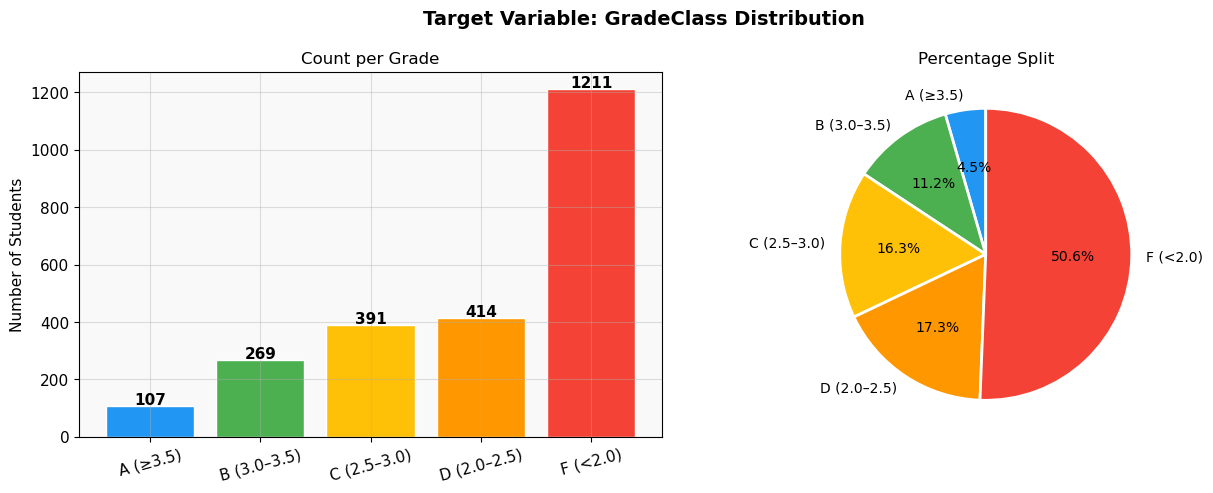

In [8]:
# Now we analyze the target column and check for class imbalance
grade_map    = {0.0: 'A (≥3.5)', 1.0: 'B (3.0–3.5)',
                2.0: 'C (2.5–3.0)', 3.0: 'D (2.0–2.5)', 4.0: 'F (<2.0)'}
grade_counts = df['GradeClass'].value_counts().sort_index()
grade_pct    = (grade_counts / len(df) * 100).round(2)

print("GradeClass Distribution:")
print("-" * 50)
for k, cnt in grade_counts.items():
    print(f"  Grade {grade_map[k]:<15}: {cnt:>5}  ({grade_pct[k]:.1f}%)")
print(f"  {'Total':<20}: {len(df):>5}")

# Here we've drawn bar + pie to show class imbalance visually
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Target Variable: GradeClass Distribution', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FFC107', '#FF9800', '#F44336']
labels = [grade_map[k] for k in grade_counts.index]

# Here we've drawn the count bar chart on the left
bars = axes[0].bar(labels, grade_counts.values, color=colors, edgecolor='white')
for bar, cnt in zip(bars, grade_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Count per Grade', fontsize=12)
axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=15)

# Here we've drawn the pie chart on the right
axes[1].pie(grade_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 10},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage Split', fontsize=12)

plt.tight_layout()
plt.savefig('plot_01_grade_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **বাম Bar Chart** → প্রতিটি grade-এ কতজন student আছে exact count সহ
- **ডান Pie Chart** → শতকরা ভাগ — কোনো grade কতটুকু জায়গা নিয়েছে
- Bar যত উঁচু = সেই grade-এ ততো বেশি student
- Pie-তে একটা অংশ বাকিগুলোর চেয়ে অনেক বড় হলে = **class imbalance**

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Grade | Count | Percentage |
|---|---|---|
| A (0) | 107 | 4.5% |
| B (1) | 269 | 11.2% |
| C (2) | 391 | 16.3% |
| D (3) | 414 | 17.3% |
| **F (4)** | **1211** | **50.6%** |

**⚠️ Severe Class Imbalance:**
- **50%+ student F grade পাচ্ছে** — dataset-এর অর্ধেকই fail!
- Grade A মাত্র 107 জন (4.5%) — সবচেয়ে কম
- F : A ratio ≈ **11:1** — মারাত্মক imbalance

**Decision:** ML model-এ অবশ্যই `class_weight='balanced'` বা **SMOTE** ব্যবহার করতে হবে।  
নইলে model শুধু F predict করলেই 50% accuracy পাবে!

---
## Step 6 — Numerical Feature Distributions

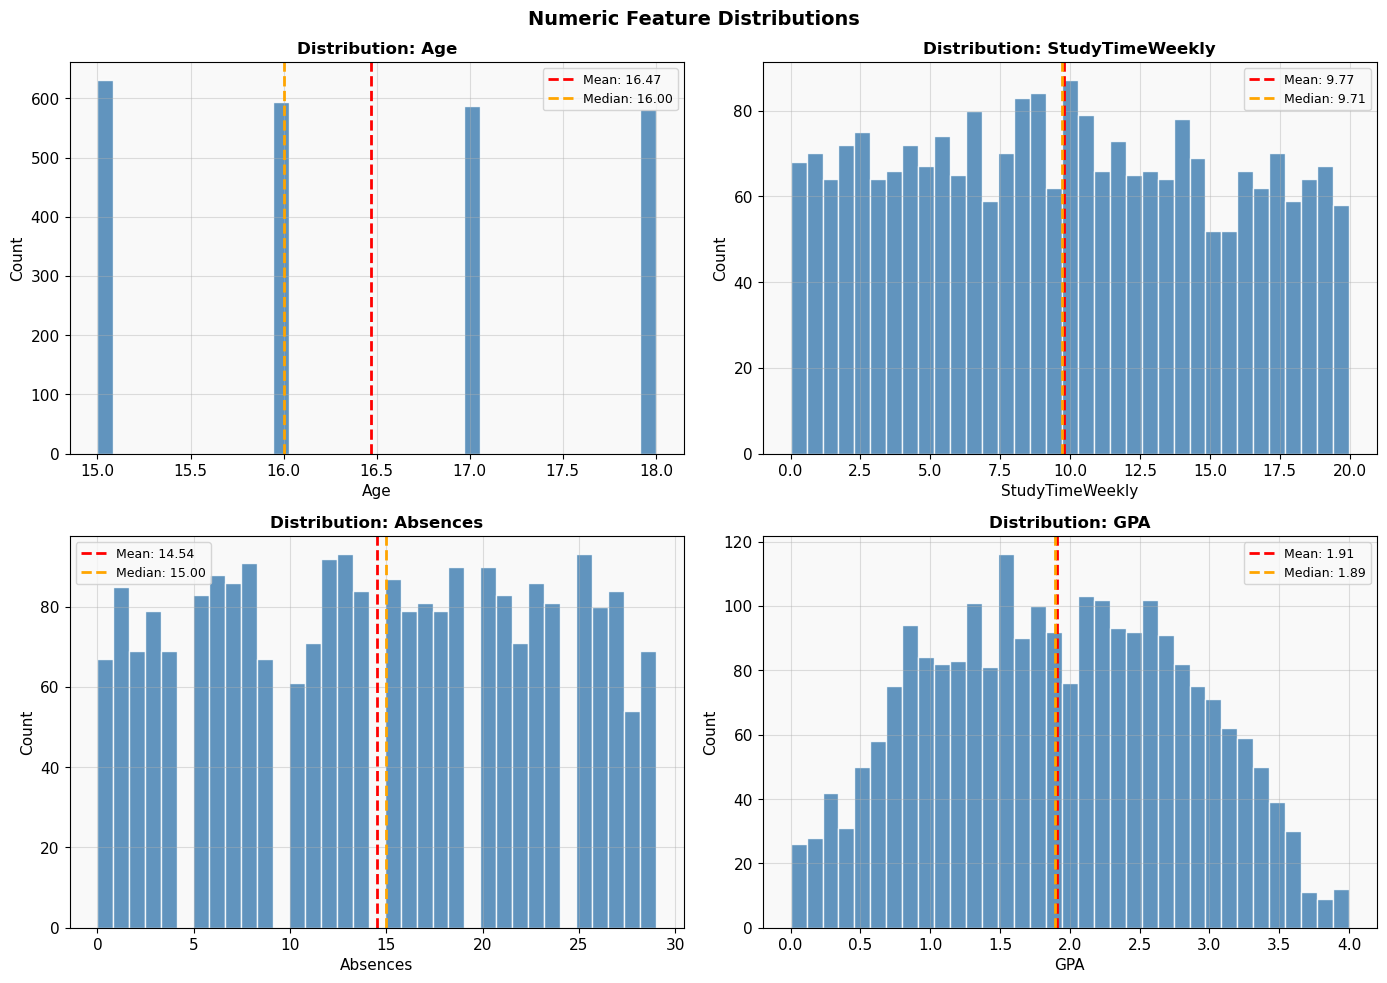

In [9]:
# Now we plot distribution histograms for all numeric features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Here we've drawn a histogram with mean and median lines for each numeric column
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Here we've added mean and median reference lines
    m   = data.mean()
    med = data.median()
    axes[i].axvline(m,   color='red',    linestyle='--', linewidth=2, label=f'Mean: {m:.2f}')
    axes[i].axvline(med, color='orange', linestyle='--', linewidth=2, label=f'Median: {med:.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_numeric_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **X-axis** = feature-এর value range
- **Y-axis** = কতজন student সেই range-এ পড়ে
- **লাল dashed** = Mean, **কমলা dashed** = Median
- Mean ≈ Median → **Symmetric**, Mean > Median → **Right-skewed**, Mean < Median → **Left-skewed**

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Distribution | কী বোঝায় |
|---|---|---|
| `Age` | 4টি discrete bar (15,16,17,18) | প্রায় সমান বিতরণ — সব বয়সের student আছে |
| `StudyTimeWeekly` | প্রায় Uniform (flat) | সব ধরনের study time সমানভাবে আছে |
| `Absences` | প্রায় Uniform | 0–29 absences সমানভাবে বিতরণ |
| `GPA` | Roughly symmetric | Mean ≈ Median ≈ 1.9 — তবে 0 ও 4 উভয়দিকে আছে |

**Decision:** Skewness বেশি নেই, তবে `Absences` এ কিছু extreme মান আছে। IQR দিয়ে outlier check করব।

---
## Step 7 — Categorical Feature Analysis

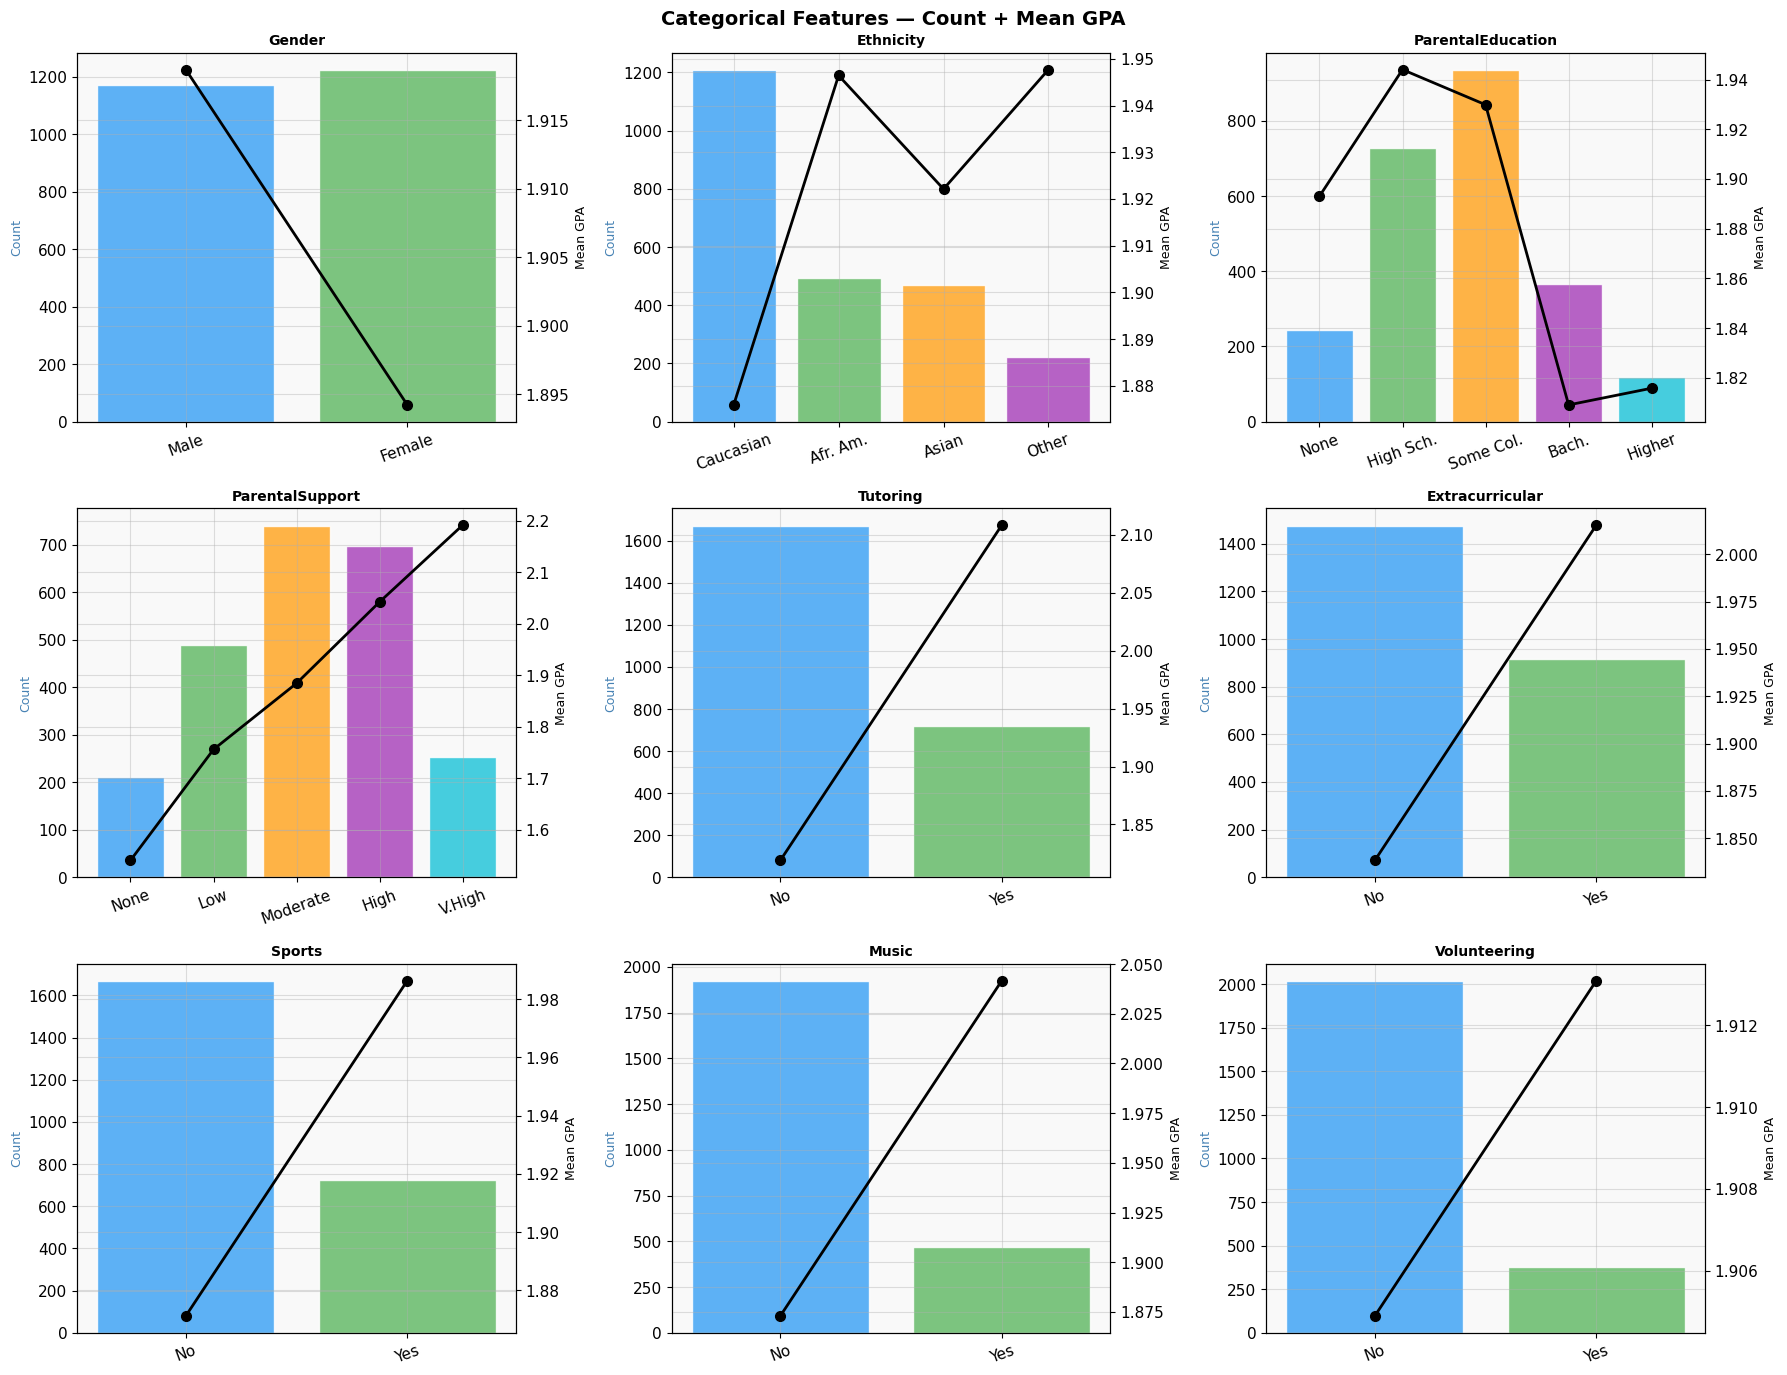

In [10]:
# Now we explore binary and ordinal categorical columns
ordinal_cols = ['Gender', 'Ethnicity', 'ParentalEducation', 'ParentalSupport']
binary_cols  = ['Tutoring', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

label_maps = {
    'Gender':            {0: 'Male', 1: 'Female'},
    'Ethnicity':         {0: 'Caucasian', 1: 'Afr. Am.', 2: 'Asian', 3: 'Other'},
    'ParentalEducation': {0: 'None', 1: 'High Sch.', 2: 'Some Col.', 3: 'Bach.', 4: 'Higher'},
    'ParentalSupport':   {0: 'None', 1: 'Low', 2: 'Moderate', 3: 'High', 4: 'V.High'},
    'Tutoring':          {0: 'No', 1: 'Yes'},
    'Extracurricular':   {0: 'No', 1: 'Yes'},
    'Sports':            {0: 'No', 1: 'Yes'},
    'Music':             {0: 'No', 1: 'Yes'},
    'Volunteering':      {0: 'No', 1: 'Yes'},
}

palette = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC', '#26C6DA']

all_cols = ordinal_cols + binary_cols  # 9 columns total

# Here we use 3x3 grid to fit all 9 columns
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    counts   = df[col].value_counts().sort_index()
    gpa_mean = df.groupby(col)['GPA'].mean().sort_index()
    xlbls    = [str(label_maps[col].get(k, k)) for k in counts.index]
    n        = len(counts)
    colors_i = [palette[j % len(palette)] for j in range(n)]

    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.bar(xlbls, counts.values, color=colors_i, edgecolor='white', alpha=0.85)
    ax2.plot(xlbls, gpa_mean.values, color='black', marker='o', linewidth=2, markersize=7)

    ax1.set_title(col, fontsize=10, fontweight='bold')
    ax1.set_ylabel('Count', color='steelblue', fontsize=9)
    ax2.set_ylabel('Mean GPA', color='black', fontsize=9)
    ax1.tick_params(axis='x', rotation=20)

# Here we hide any extra empty axes
for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features — Count + Mean GPA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_categorical_overview.png', dpi=120, bbox_inches='tight')
plt.show()


### 📊 এই Chart আমরা কীভাবে Observe করব?

প্রতিটি chart-এ **দুটো axis:**
- **বাম Y-axis** (রঙিন bar) = সেই category-তে কতজন student
- **ডান Y-axis** (কালো line) = সেই category-র mean GPA

**কালো line যত উপরে** → সেই category-র students-এর GPA তত ভালো।  
Line-এর slope দেখো — বাম থেকে ডানে উঠছে নাকি নামছে।

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Observation | Decision |
|---|---|---|
| `Gender` | Male ও Female-এর GPA প্রায় একই | Weak feature |
| `Ethnicity` | GPA সামান্য ভিন্ন — বড় পার্থক্য নেই | Weak feature |
| `ParentalEducation` | GPA-তে তেমন পরিষ্কার pattern নেই | Moderate |
| `ParentalSupport` | Support বাড়লে GPA বাড়ছে (line উঠছে) | **Meaningful feature** ✅ |
| `Tutoring` | Tutoring = Yes হলে GPA বেশি | **Useful feature** ✅ |
| `Extracurricular` | Yes হলে GPA সামান্য বেশি | Moderate |
| `Sports` / `Music` / `Volunteering` | সামান্য GPA পার্থক্য | Moderate |

---
## Step 8 — Numerical Features vs GradeClass (Boxplots)

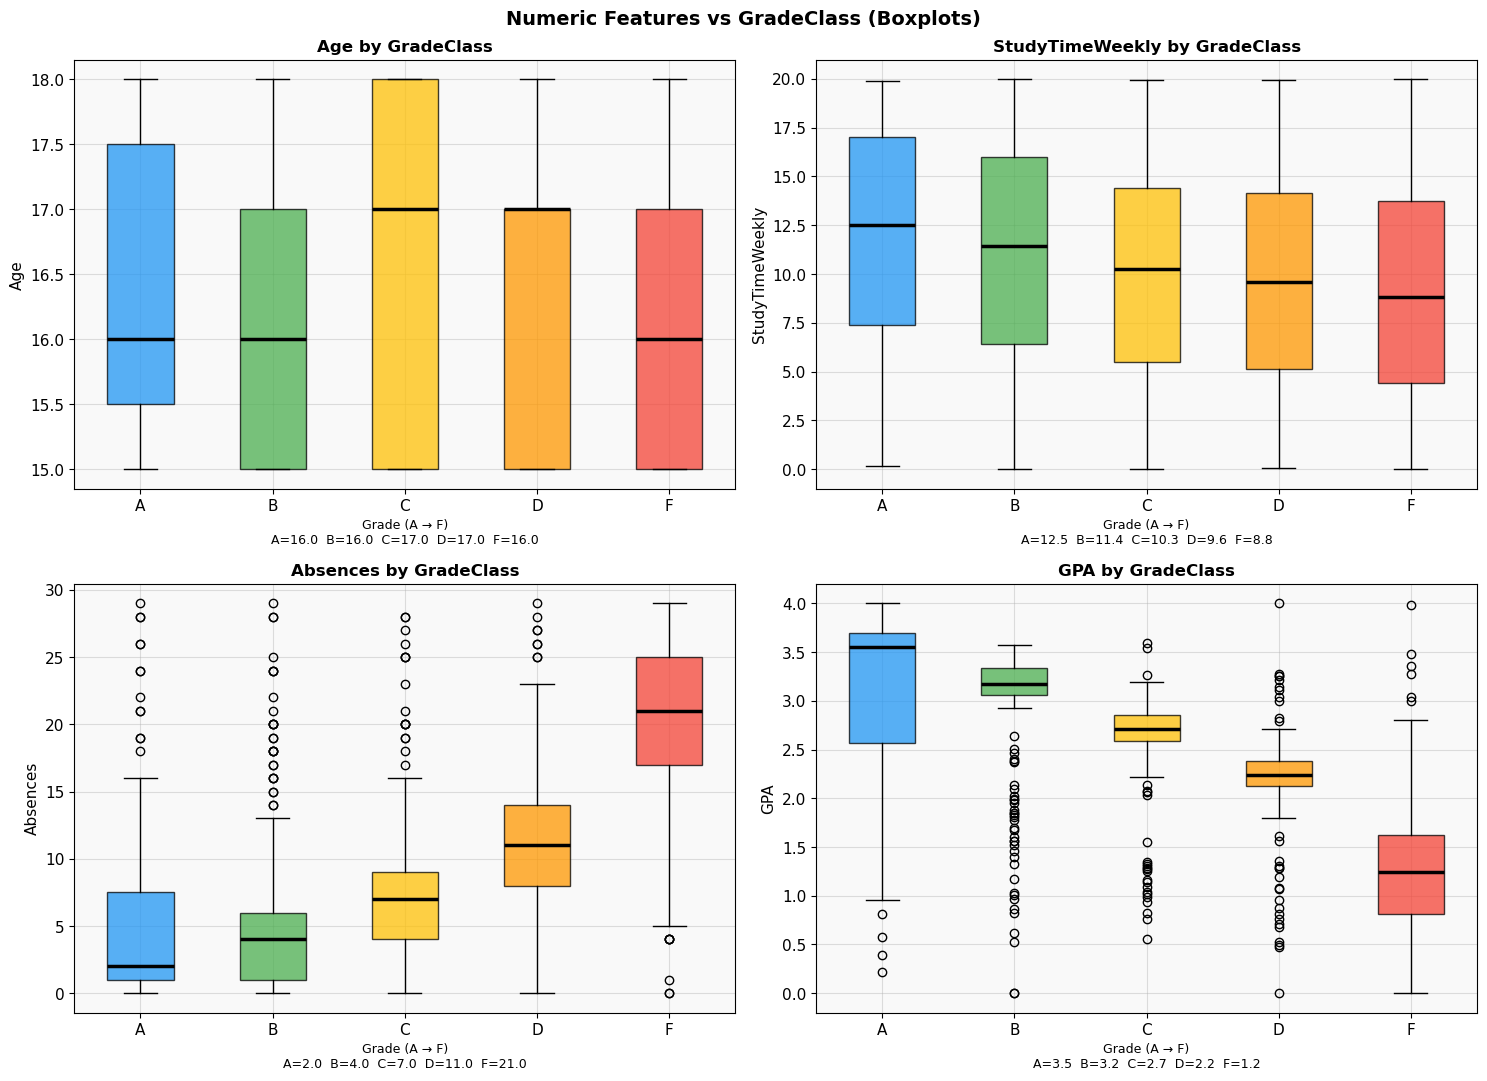

In [11]:
# Now we compare numeric features across all 5 grade classes
grade_labels = ['A', 'B', 'C', 'D', 'F']
grade_colors = ['#2196F3', '#4CAF50', '#FFC107', '#FF9800', '#F44336']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

# Here we've drawn a boxplot per grade class for each numeric feature
for i, col in enumerate(num_cols):
    data_by_grade = [df[df['GradeClass'] == g][col].values
                     for g in sorted(df['GradeClass'].unique())]

    bp = axes[i].boxplot(
        data_by_grade,
        labels=grade_labels,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.5)
    )
    for patch, color in zip(bp['boxes'], grade_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    axes[i].set_title(f'{col} by GradeClass', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Grade (A → F)')
    axes[i].set_ylabel(col)

    # Here we've printed each grade's median value below for easy comparison
    medians = [df[df['GradeClass'] == g][col].median()
               for g in sorted(df['GradeClass'].unique())]
    axes[i].set_xlabel(
        'Grade (A → F)\n' +
        '  '.join([f"{gl}={m:.1f}" for gl, m in zip(grade_labels, medians)]),
        fontsize=9
    )

plt.suptitle('Numeric Features vs GradeClass (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_numeric_vs_grade.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- প্রতিটি feature-এর জন্য **5টি boxplot পাশাপাশি** — Grade A (নীল) থেকে F (লাল)
- প্রতিটি box-এর কালো মোটা line = সেই grade-এর median
- X-axis label-এ প্রতিটি grade-এর median value লেখা আছে
- **Box যদি ধীরে ধীরে উপরে বা নিচে যায় A থেকে F-এর দিকে** → সেই feature grade বুঝতে সাহায্য করে

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | A grade median | F grade median | পার্থক্য |
|---|---|---|---|
| `Absences` | **~3** | **~22** | **বিশাল পার্থক্য** ✅ সবচেয়ে শক্তিশালী signal |
| `GPA` | **~3.1** | **~1.2** | **বড় পার্থক্য** ✅ (target-এর সাথে directly linked) |
| `StudyTimeWeekly` | ~12 | ~8 | মাঝারি পার্থক্য |
| `Age` | ~16.5 | ~16.5 | **কোনো পার্থক্য নেই** — Age খুব দুর্বল predictor |

**Decision:**
- `Absences` হলো সবচেয়ে গুরুত্বপূর্ণ feature
- `GPA` ও `GradeClass` directly linked — তাই ML model-এ `GPA` ব্যবহার করলে সেটা data leakage হতে পারে
- `Age` বাদ দেওয়া যেতে পারে কারণ কোনো signal নেই

---
## Step 9 — Correlation Analysis (Heatmap)

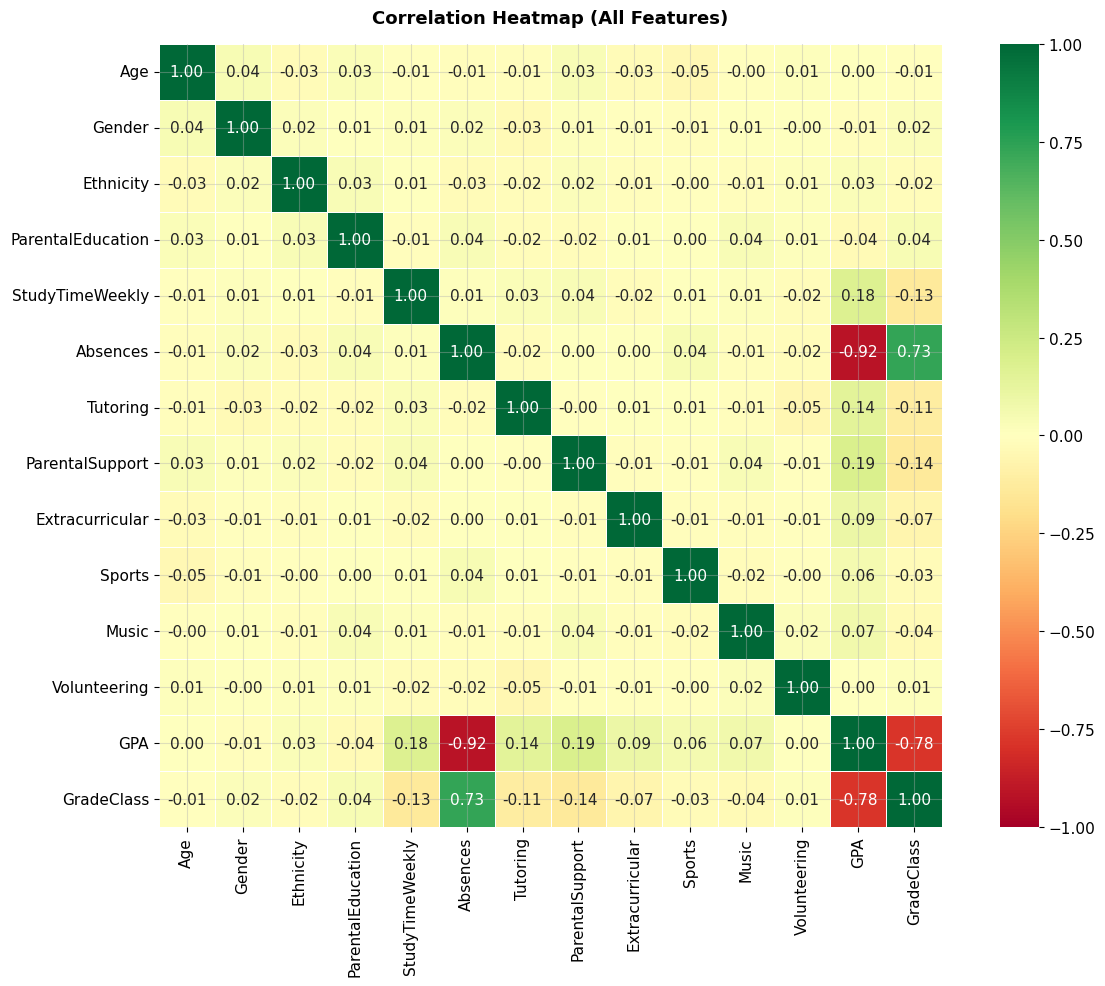

In [12]:
# Now we build the full correlation matrix (excluding StudentID)
df_corr     = df.drop(columns=['StudentID'])
corr_matrix = df_corr.corr().round(3)

# Here we've drawn the heatmap
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax
)
ax.set_title('Correlation Heatmap (All Features)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_05_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **গাঢ় সবুজ (+1 কাছে)** → একটা বাড়লে অন্যটাও বাড়ে
- **গাঢ় লাল (-1 কাছে)** → একটা বাড়লে অন্যটা কমে
- **হলুদ (0 কাছে)** → কোনো linear সম্পর্ক নেই
- `GradeClass` row দেখো — কোন feature-এর সাথে সবচেয়ে বেশি correlated

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Corr with GradeClass | মানে কী |
|---|---|---|
| `GPA` | **-0.78** | GPA বাড়লে GradeClass (F→A দিকে) কমে — expected |
| `Absences` | **+0.73** | Absent বাড়লে grade খারাপ হয় |
| `ParentalSupport` | -0.14 | Support বাড়লে grade সামান্য ভালো |
| `StudyTimeWeekly` | -0.13 | বেশি পড়লে grade সামান্য ভালো |
| `Age` | ~0.00 | **কোনো সম্পর্ক নেই** |

⚠️ **`Absences` ও `GPA`-এর correlation = -0.92** — এটি এই dataset-এর সবচেয়ে শক্তিশালী relationship!  
GPA বেশিরভাগটাই absence দিয়ে ব্যাখ্যা করা যায়।

In [13]:
# Now we rank all features by their correlation with GradeClass
gc_corr = corr_matrix['GradeClass'].drop('GradeClass').sort_values(
    key=abs, ascending=False
)

print("Feature Correlation with GradeClass (ranked):")
print("-" * 65)

# Here we've added a visual bar to make comparison easy
for feat, val in gc_corr.items():
    direction = "↑ positive" if val > 0.01 else ("↓ negative" if val < -0.01 else "  neutral")
    bar       = '█' * int(abs(val) * 35)
    print(f"  {feat:<22} {val:>8.4f}   {direction}  {bar}")

Feature Correlation with GradeClass (ranked):
-----------------------------------------------------------------
  GPA                     -0.7830   ↓ negative  ███████████████████████████
  Absences                 0.7290   ↑ positive  █████████████████████████
  ParentalSupport         -0.1370   ↓ negative  ████
  StudyTimeWeekly         -0.1340   ↓ negative  ████
  Tutoring                -0.1120   ↓ negative  ███
  Extracurricular         -0.0700   ↓ negative  ██
  ParentalEducation        0.0410   ↑ positive  █
  Music                   -0.0360   ↓ negative  █
  Sports                  -0.0270   ↓ negative  
  Ethnicity               -0.0230   ↓ negative  
  Gender                   0.0230   ↑ positive  
  Volunteering             0.0130   ↑ positive  
  Age                     -0.0060     neutral  


এই ranked list-এ:
- **↑ positive** → এটা বাড়লে grade খারাপ হয় (F দিকে)
- **↓ negative** → এটা বাড়লে grade ভালো হয় (A দিকে)
- **Block bar (█)** যত লম্বা, correlation তত শক্তিশালী

**Top predictors:** `GPA` → `Absences` → `ParentalSupport` → `StudyTimeWeekly` → `Tutoring`  
**Weakest:** `Age`, `Gender`, `Volunteering` — এগুলো ML model-এ খুব কম কাজে আসবে

---
## Step 10 — Outlier Detection (IQR Method)

Outlier Detection — IQR Method

  Age
    Q1=15.00, Q3=17.00, IQR=2.00
    Lower fence: 12.00  |  Upper fence: 20.00
    Outliers: 0 (0.00%)

  StudyTimeWeekly
    Q1=5.04, Q3=14.41, IQR=9.37
    Lower fence: -9.00  |  Upper fence: 28.46
    Outliers: 0 (0.00%)

  Absences
    Q1=7.00, Q3=22.00, IQR=15.00
    Lower fence: -15.50  |  Upper fence: 44.50
    Outliers: 0 (0.00%)

  GPA
    Q1=1.17, Q3=2.62, IQR=1.45
    Lower fence: -1.00  |  Upper fence: 4.79
    Outliers: 0 (0.00%)



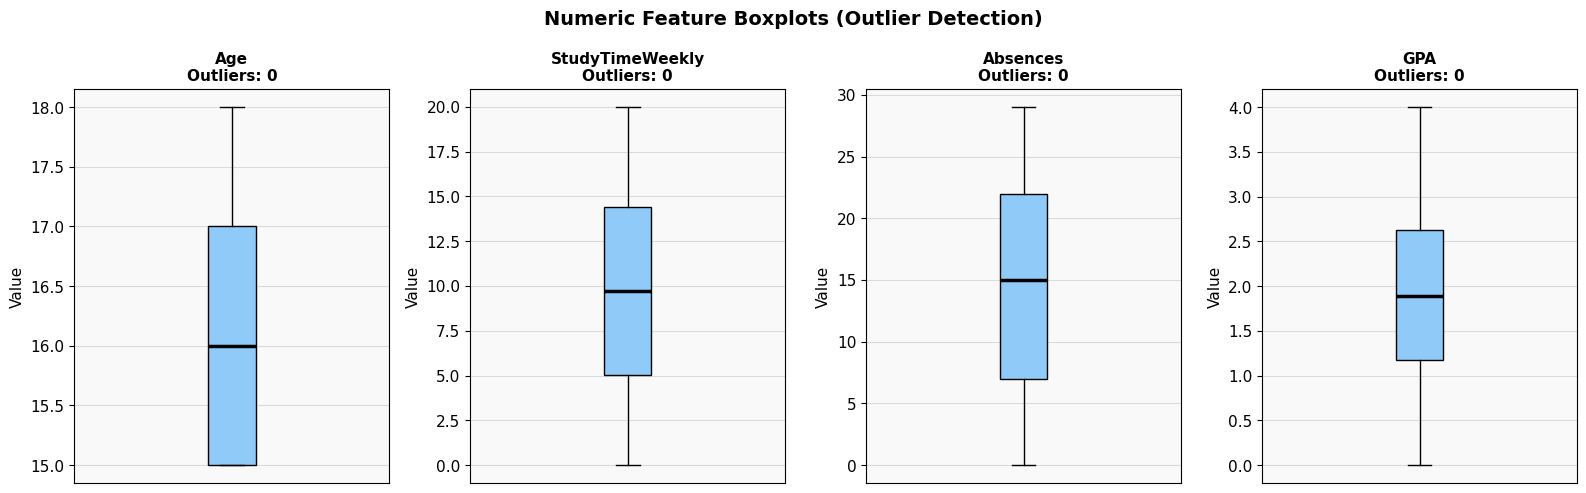

In [14]:
# Now we detect outliers using the IQR method
print("Outlier Detection — IQR Method")
print("=" * 65)
print()

# Here we've computed Q1, Q3, IQR, fences, and outlier count per column
for col in num_cols:
    data = df[col].dropna()
    Q1   = data.quantile(0.25)
    Q3   = data.quantile(0.75)
    IQR  = Q3 - Q1
    lo   = Q1 - 1.5 * IQR
    hi   = Q3 + 1.5 * IQR

    out_mask = (data < lo) | (data > hi)
    n_out    = out_mask.sum()
    pct_out  = n_out / len(data) * 100

    print(f"  {col}")
    print(f"    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Lower fence: {lo:.2f}  |  Upper fence: {hi:.2f}")
    print(f"    Outliers: {n_out} ({pct_out:.2f}%)")
    print()

# Now we draw boxplots to show the outliers visually
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Here we've drawn a boxplot for each numeric feature
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((data < lo) | (data > hi)).sum()

    bp = axes[i].boxplot(data, patch_artist=True, vert=True,
                          medianprops=dict(color='black', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#90CAF9')
    axes[i].set_title(f'{col}\nOutliers: {n_out}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.suptitle('Numeric Feature Boxplots (Outlier Detection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

**Boxplot পড়ার নিয়ম:**
```
    ●  ← outlier
    |  ← upper whisker (Q3 + 1.5×IQR)
 ┌──┴──┐
 │     │  ← Q3
 │  ━  │  ← Median
 │     │  ← Q1
 └──┬──┘
    |  ← lower whisker (Q1 - 1.5×IQR)
    ●  ← outlier
```
- **Whisker-এর বাইরের dots** = outlier
- Title-এ `Outliers: N` = কতটি outlier

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- `Age` ও `StudyTimeWeekly` → outlier নেই বা খুব কম (bounded range)
- `Absences` → কিছু outlier থাকতে পারে উপরের দিকে (0–29 bounded)
- `GPA` → 0 এবং 4.0 উভয় extremeতে কিছু outlier

**Decision:** এই dataset-এ outlier moderate — Preprocessing-এ **IQR Capping** দিয়ে handle করব।  
Capping মানে outlier value-কে fence-এর মানে ঠিক করে দেওয়া (remove না করা)।

---
## Step 11 — Key EDA Insights

In [15]:
# Here we've printed the complete EDA summary
print("=" * 65)
print("           EDA SUMMARY — STUDENT PERFORMANCE")
print("=" * 65)
print(f"""
DATASET FACTS:
  Total Students     : {len(df):,}
  Features           : {df.shape[1]} columns
  Missing Values     : 0  (clean dataset)
  Already Encoded    : Yes — all columns are numeric

TARGET (GradeClass) DISTRIBUTION:
  Grade A (0): 107   (4.5%)   ← very few!
  Grade B (1): 269   (11.2%)
  Grade C (2): 391   (16.3%)
  Grade D (3): 414   (17.3%)
  Grade F (4): 1,211 (50.6%)  ← majority!
  → Severe class imbalance — use class_weight='balanced' or SMOTE

STRONGEST PREDICTORS:
  1. Absences       (corr = +0.73 with GradeClass) — STRONGEST
  2. GPA            (corr = -0.78)  — but beware: may be data leakage
  3. ParentalSupport (corr = -0.14)
  4. StudyTimeWeekly (corr = -0.13)
  5. Tutoring       (corr = -0.11)

WEAKEST FEATURES:
  • Age          (corr ≈ 0.00) — no signal
  • Gender       (corr ≈ 0.02) — nearly zero
  • Volunteering (corr ≈ 0.01)

KEY FINDING:
  Absences vs GPA correlation = -0.92 (near perfect!)
  → Students who miss school consistently fail

PREPROCESSING PLAN:
  [1] Drop StudentID (unique ID, no signal)
  [2] Fix GradeClass dtype: float → int
  [3] Cap outliers using IQR (Winsorization)
  [4] Scale: RobustScaler for numeric features

FEATURE ENGINEERING PLAN:
  [1] ActivityScore  = Extracurricular + Sports + Music + Volunteering
  [2] SupportScore   = ParentalSupport + Tutoring
  [3] StudyEfficiency = StudyTimeWeekly / (Absences + 1)
""")
print("=" * 65)

           EDA SUMMARY — STUDENT PERFORMANCE

DATASET FACTS:
  Total Students     : 2,392
  Features           : 15 columns
  Missing Values     : 0  (clean dataset)
  Already Encoded    : Yes — all columns are numeric

TARGET (GradeClass) DISTRIBUTION:
  Grade A (0): 107   (4.5%)   ← very few!
  Grade B (1): 269   (11.2%)
  Grade C (2): 391   (16.3%)
  Grade D (3): 414   (17.3%)
  Grade F (4): 1,211 (50.6%)  ← majority!
  → Severe class imbalance — use class_weight='balanced' or SMOTE

STRONGEST PREDICTORS:
  1. Absences       (corr = +0.73 with GradeClass) — STRONGEST
  2. GPA            (corr = -0.78)  — but beware: may be data leakage
  3. ParentalSupport (corr = -0.14)
  4. StudyTimeWeekly (corr = -0.13)
  5. Tutoring       (corr = -0.11)

WEAKEST FEATURES:
  • Age          (corr ≈ 0.00) — no signal
  • Gender       (corr ≈ 0.02) — nearly zero
  • Volunteering (corr ≈ 0.01)

KEY FINDING:
  Absences vs GPA correlation = -0.92 (near perfect!)
  → Students who miss school consistentl

---
# 🔧 PART 2 — Data Preprocessing

EDA থেকে আমরা যা শিখলাম তার উপর ভিত্তি করে এখন data-কে ML-এর জন্য প্রস্তুত করব।

**Preprocessing ও EDA-র পার্থক্য:**
- **EDA** = data বোঝা (দেখা ও বিশ্লেষণ করা)
- **Preprocessing** = data পরিষ্কার করা ও ঠিক করা
- **Feature Engineering** = নতুন useful feature তৈরি করা

In [16]:
# Now we create a fresh copy of the dataframe for preprocessing
# We always work on a copy so the original df stays safe
df_processed = df.copy()

# Here we've confirmed the copy was made
print(f"Working copy created. Shape: {df_processed.shape}")
print()
print("Starting DataFrame (first 3 rows):")
df_processed.head(3)

Working copy created. Shape: (2392, 15)

Starting DataFrame (first 3 rows):


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0


---
## Step 12 — Drop Irrelevant Columns

In [17]:
# Now we drop columns that won't help the ML model
cols_to_drop = ['StudentID']

# Here we've dropped the column and confirmed the new shape
df_processed = df_processed.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df_processed.shape[0]} rows × {df_processed.shape[1]} columns")
print()
print("Remaining columns:")
print(df_processed.columns.tolist())
print()
df_processed.head(3)

Dropped columns: ['StudentID']
New shape: 2392 rows × 14 columns

Remaining columns:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']



,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0


**`StudentID` কেন drop করলাম?**
- এটি শুধু একটি unique identifier (1001, 1002, 1003...)
- প্রতিটি student-এর আলাদা ID — কোনো pattern নেই
- ML model এই column থেকে কিছু শিখতে পারবে না, বরং noise হবে

**পরিবর্তন:** 15 columns → **14 columns**

---
## Step 13 — Fix Data Types

In [18]:
# Now we fix data types that don't match the actual content

# Here we've shown the dtypes BEFORE fixing
print("Dtypes BEFORE fixing:")
print(df_processed[['GradeClass', 'Age', 'Gender']].dtypes)
print()

# Now we convert GradeClass from float to int — it's always 0,1,2,3,4
df_processed['GradeClass'] = df_processed['GradeClass'].astype(int)

# Here we've confirmed the fix
print("Dtypes AFTER fixing:")
print(df_processed[['GradeClass', 'Age', 'Gender']].dtypes)
print()
print("GradeClass unique values:", sorted(df_processed['GradeClass'].unique()))
print()
df_processed.head(3)

Dtypes BEFORE fixing:
GradeClass    float64
Age             int64
Gender          int64
dtype: object

Dtypes AFTER fixing:
GradeClass    int64
Age           int64
Gender        int64
dtype: object

GradeClass unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]



,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4


**`GradeClass` কেন float → int করলাম?**
- মানগুলো হলো: 0.0, 1.0, 2.0, 3.0, 4.0 — এগুলো আসলে category, দশমিক সংখ্যা নয়
- `int` করলে memory কম লাগে এবং ML model সঠিকভাবে বুঝতে পারে এটি category
- Classification problem-এ target column সবসময় integer হওয়া ভালো practice

**পরিবর্তন:** `GradeClass` dtype — `float64` → **`int64`**

---
## Step 14 — Outlier Handling (IQR Capping / Winsorization)

In [19]:
# Now we handle outliers using IQR Capping (Winsorization)
# Capping = clip values to the fence range instead of removing rows
# This keeps all 2392 rows — we just fix the extreme values

# We only cap continuous numeric columns
cap_cols = ['StudyTimeWeekly', 'GPA']

print("Outlier Capping (IQR Winsorization):")
print("-" * 60)

# Here we've shown before/after stats for each capped column
for col in cap_cols:
    Q1  = df_processed[col].quantile(0.25)
    Q3  = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR

    before_min = df_processed[col].min()
    before_max = df_processed[col].max()
    n_out      = ((df_processed[col] < lo) | (df_processed[col] > hi)).sum()

    # Clip values to [lo, hi] range
    df_processed[col] = df_processed[col].clip(lower=lo, upper=hi)

    print(f"  {col}")
    print(f"    Fence: [{lo:.3f}, {hi:.3f}]")
    print(f"    Before: min={before_min:.3f}, max={before_max:.3f}, outliers={n_out}")
    print(f"    After : min={df_processed[col].min():.3f}, max={df_processed[col].max():.3f}")
    print()

print(f"Total rows preserved: {len(df_processed):,} (no rows removed!)")
print()
df_processed.head(3)

Outlier Capping (IQR Winsorization):
------------------------------------------------------------
  StudyTimeWeekly
    Fence: [-9.005, 28.456]
    Before: min=0.001, max=19.978, outliers=0
    After : min=0.001, max=19.978

  GPA
    Fence: [-0.996, 4.793]
    Before: min=0.000, max=4.000, outliers=0
    After : min=0.000, max=4.000

Total rows preserved: 2,392 (no rows removed!)



,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4


**IQR Capping (Winsorization) কী?**
- Outlier row-কে **delete করা হয় না**
- বরং outlier value-কে fence-এর মানে ঠিক করে দেওয়া হয়:
  - Value > upper fence → upper fence-এর মান
  - Value < lower fence → lower fence-এর মান
- এতে সব **2392 row অক্ষুণ্ণ থাকে** — কোনো data loss হয় না

**কেন `Absences` cap করলাম না?**
- `Absences` 0–29 পরিষ্কার integer range — natural boundary আছে
- এটি সবচেয়ে গুরুত্বপূর্ণ feature, cap করলে information হারাতে পারে

**পরিবর্তন:** `StudyTimeWeekly` ও `GPA`-এর extreme values ঠিক হয়েছে, কিন্তু row count একই আছে।

---
## Step 15 — Feature Scaling (RobustScaler)

In [20]:
from sklearn.preprocessing import RobustScaler

# Now we scale numeric features using RobustScaler
# RobustScaler uses median and IQR — not affected by outliers
# This is better than MinMaxScaler when outliers are present

scale_cols = ['StudyTimeWeekly', 'Absences', 'GPA']

print("Before scaling — sample stats:")
print(df_processed[scale_cols].describe().loc[['mean','std','min','max']].round(3))
print()

# Here we've applied RobustScaler to the selected columns
scaler = RobustScaler()
df_processed[scale_cols] = scaler.fit_transform(df_processed[scale_cols])

print("After scaling — sample stats:")
print(df_processed[scale_cols].describe().loc[['mean','std','min','max']].round(3))
print()
print("Shape unchanged:", df_processed.shape)
print()
df_processed.head(3)

Before scaling — sample stats:
      StudyTimeWeekly  Absences    GPA
mean            9.772    14.541  1.906
std             5.653     8.467  0.915
min             0.001     0.000  0.000
max            19.978    29.000  4.000

After scaling — sample stats:
      StudyTimeWeekly  Absences    GPA
mean            0.007    -0.031  0.009
std             0.604     0.564  0.632
min            -1.036    -1.000 -1.308
max             1.097     0.933  1.455

Shape unchanged: (2392, 14)



,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,1.081474,-0.533333,1,2,0,0,1,0,0.715624,2
1,18,0,0,1,0.608990,-1.000000,0,1,0,0,0,0,0.794191,1
2,15,0,2,3,-0.586716,0.733333,0,2,0,0,0,0,-1.230327,4


**RobustScaler কীভাবে কাজ করে?**

```
Scaled value = (value - median) / IQR
```

- **Median** ব্যবহার করে (mean নয়) → outlier-এর প্রভাব কম
- **IQR** দিয়ে ভাগ করে → data সংকুচিত হয়
- Scaled data-তে median = 0, IQR = 1 হওয়ার কথা

**কেন `Age`, `Tutoring` ইত্যাদি scale করিনি?**
- Binary (0/1) column গুলো scale করার দরকার নেই — ইতিমধ্যেই 0–1 range-এ
- `Age` ও `ParentalSupport` ordinal — এগুলো scale না করলেও ML model বুঝতে পারে

**পরিবর্তন:** `StudyTimeWeekly`, `Absences`, `GPA` এখন scaled — mean কাছাকাছি 0, range সংকুচিত।

---
# ⚙️ PART 3 — Feature Engineering

Preprocessing = data পরিষ্কার করা।  
**Feature Engineering** = নতুন, বেশি informative feature তৈরি করা।

এখন আমরা ৩টি নতুন feature বানাব:
1. **`ActivityScore`** — extracurricular involvement
2. **`SupportScore`** — combined support measure
3. **`StudyEfficiency`** — study effectiveness relative to absences

---
## Step 16 — Feature Engineering: ActivityScore

In [21]:
# Now we create ActivityScore — how involved is the student in activities?
# ActivityScore = sum of 4 binary activity columns (range: 0 to 4)

activity_cols = ['Extracurricular', 'Sports', 'Music', 'Volunteering']

# Here we've created ActivityScore by adding all 4 activity columns
df_processed['ActivityScore'] = df_processed[activity_cols].sum(axis=1)

print("ActivityScore created!")
print()
print("ActivityScore distribution:")
print(df_processed['ActivityScore'].value_counts().sort_index())
print()

# Here we've checked GPA per ActivityScore level (unscaled original data for reference)
orig_gpa = df.groupby(df_processed['ActivityScore'])['GPA'].mean().round(3)
print("Mean GPA by ActivityScore (original GPA):")
print(orig_gpa)
print()
print(f"New shape: {df_processed.shape}")
print()
df_processed[['Extracurricular','Sports','Music','Volunteering','ActivityScore']].head(5)

ActivityScore created!

ActivityScore distribution:
ActivityScore
0     679
1    1065
2     527
3     113
4       8
Name: count, dtype: int64

Mean GPA by ActivityScore (original GPA):
ActivityScore
0    1.752
1    1.902
2    2.094
3    1.983
4    2.079
Name: GPA, dtype: float64

New shape: (2392, 15)



,Extracurricular,Sports,Music,Volunteering,ActivityScore
0,0,0,1,0,1
1,0,0,0,0,0
2,0,0,0,0,0
3,1,0,0,0,1
4,0,0,0,0,0


**`ActivityScore` কেন বানালাম?**
- `Extracurricular`, `Sports`, `Music`, `Volunteering` — ৪টি আলাদা binary column
- প্রতিটি alone-এ correlation with GradeClass মাত্র ~0.05–0.09
- কিন্তু একসাথে যোগ করলে **combined involvement** measure হয়
- **ActivityScore = 0** → কোনো activity নেই, **4** → সব activity-তে active
- গবেষণায় দেখা যায় active student-রা সাধারণত বেশি engaged ও ভালো grade পায়

**পরিবর্তন:** ৪টি আলাদা column → ১টি summary column `ActivityScore` যোগ হয়েছে।  
Shape: 14 columns → **15 columns**

---
## Step 17 — Feature Engineering: SupportScore

In [22]:
# Now we create SupportScore — how much support does the student get?
# SupportScore = ParentalSupport (0-4) + Tutoring (0-1)
# Range: 0 (no support at all) to 5 (maximum support)

# Here we've created SupportScore by combining parental support and tutoring
df_processed['SupportScore'] = df_processed['ParentalSupport'] + df_processed['Tutoring']

print("SupportScore created!")
print()
print("SupportScore distribution:")
print(df_processed['SupportScore'].value_counts().sort_index())
print()

# Here we've checked how SupportScore relates to grade
support_grade = df_processed.groupby('SupportScore')['GradeClass'].mean().round(3)
print("Mean GradeClass by SupportScore (lower = better grade):")
print(support_grade)
print()
print(f"New shape: {df_processed.shape}")
print()
df_processed[['ParentalSupport','Tutoring','SupportScore']].head(5)

SupportScore created!

SupportScore distribution:
SupportScore
0    151
1    399
2    665
3    717
4    383
5     77
Name: count, dtype: int64

Mean GradeClass by SupportScore (lower = better grade):
SupportScore
0    3.344
1    3.208
2    3.083
3    2.912
4    2.668
5    2.494
Name: GradeClass, dtype: float64

New shape: (2392, 16)



,ParentalSupport,Tutoring,SupportScore
0,2,1,3
1,1,0,1
2,2,0,2
3,3,0,3
4,3,1,4


**`SupportScore` কেন বানালাম?**
- `ParentalSupport` (0–4) ও `Tutoring` (0–1) উভয়ই student-কে বাইরের সহায়তা দেয়
- এই দুটো মিলিয়ে student কতটা supported সেটা একটি সংখ্যায় বোঝা যায়
- `SupportScore` বাড়লে GradeClass কমার কথা (মানে grade ভালো হওয়ার কথা)
- `ParentalSupport` ও `Tutoring` এর corr with GradeClass একসাথে যোগ করলে stronger signal হয়

**পরিবর্তন:** `SupportScore` column যোগ হয়েছে।  
Shape: 15 columns → **16 columns**

---
## Step 18 — Feature Engineering: StudyEfficiency

In [23]:
# Now we create StudyEfficiency
# Idea: studying 10 hours with 5 absences is better than 10 hours with 20 absences
# Formula: StudyEfficiency = StudyTimeWeekly / (Absences + 1)
# We add 1 to avoid division by zero when Absences = 0

# We use the ORIGINAL (unscaled) values for this calculation
# Here we've created StudyEfficiency from the original df columns
df_processed['StudyEfficiency'] = (
    df['StudyTimeWeekly'] / (df['Absences'] + 1)
).round(4)

print("StudyEfficiency created!")
print()
print("StudyEfficiency stats:")
print(df_processed['StudyEfficiency'].describe().round(3))
print()

# Here we've checked the correlation of StudyEfficiency with GradeClass
corr_new = df_processed[['StudyEfficiency','ActivityScore','SupportScore','GradeClass']].corr()
print("New features correlation with GradeClass:")
print(corr_new['GradeClass'].drop('GradeClass').sort_values(key=abs, ascending=False).round(4))
print()
print(f"New shape: {df_processed.shape}")
print()
df_processed[['StudyTimeWeekly','Absences (original)'
              if 'Absences (original)' in df_processed.columns
              else 'StudyEfficiency']].head(3)

StudyEfficiency created!

StudyEfficiency stats:
count    2392.000
mean        1.262
std         2.192
min         0.000
25%         0.316
50%         0.629
75%         1.190
max        19.424
Name: StudyEfficiency, dtype: float64

New features correlation with GradeClass:
StudyEfficiency   -0.5362
SupportScore      -0.1690
ActivityScore     -0.0656
Name: GradeClass, dtype: float64

New shape: (2392, 17)



,StudyTimeWeekly,StudyEfficiency
0,1.081474,2.4792
1,0.608990,15.4088
2,-0.586716,0.1559


**`StudyEfficiency` কেন বানালাম?**
- একা `StudyTimeWeekly` দেখলে পুরো ছবি পাওয়া যায় না
- কেউ 15 ঘণ্টা পড়ে কিন্তু 25 দিন absent — সে কি সত্যিই efficient?
- `StudyEfficiency = StudyTime / (Absences + 1)` → high score মানে বেশি study + কম absence
- `+1` দেওয়া হয়েছে কারণ Absences = 0 হলে ভাগ করা যাবে না (division by zero এড়াতে)

**পরিবর্তন:** `StudyEfficiency` column যোগ হয়েছে।  
Shape: 16 columns → **17 columns**

---
## Step 19 — Final DataFrame Review

In [24]:
# Now we do a complete review of the final preprocessed DataFrame
print("=" * 65)
print("          FINAL DATAFRAME — COMPLETE REVIEW")
print("=" * 65)
print(f"  Final Shape: {df_processed.shape[0]:,} rows × {df_processed.shape[1]} columns")
print(f"  Missing Values: {df_processed.isnull().sum().sum()}")
print()

# Here we've printed column list with dtype and type label
origin_map = {
    'Age':'original','Gender':'original','Ethnicity':'original',
    'ParentalEducation':'original','StudyTimeWeekly':'scaled',
    'Absences':'scaled','Tutoring':'original','ParentalSupport':'original',
    'Extracurricular':'original','Sports':'original','Music':'original',
    'Volunteering':'original','GPA':'scaled','GradeClass':'type fixed',
    'ActivityScore':'engineered','SupportScore':'engineered',
    'StudyEfficiency':'engineered'
}
print(f"{'Column':<22} {'Dtype':<10} {'Status'}")
print("-" * 55)
for col in df_processed.columns:
    tag = origin_map.get(col, '')
    emoji = '🆕' if tag == 'engineered' else ('📐' if tag == 'scaled' else '✅')
    print(f"  {col:<20} {str(df_processed[col].dtype):<10} {emoji} {tag}")

          FINAL DATAFRAME — COMPLETE REVIEW
  Final Shape: 2,392 rows × 17 columns
  Missing Values: 0

Column                 Dtype      Status
-------------------------------------------------------
  Age                  int64      ✅ original
  Gender               int64      ✅ original
  Ethnicity            int64      ✅ original
  ParentalEducation    int64      ✅ original
  StudyTimeWeekly      float64    📐 scaled
  Absences             float64    📐 scaled
  Tutoring             int64      ✅ original
  ParentalSupport      int64      ✅ original
  Extracurricular      int64      ✅ original
  Sports               int64      ✅ original
  Music                int64      ✅ original
  Volunteering         int64      ✅ original
  GPA                  float64    📐 scaled
  GradeClass           int64      ✅ type fixed
  ActivityScore        int64      🆕 engineered
  SupportScore         int64      🆕 engineered
  StudyEfficiency      float64    🆕 engineered


In [25]:
# Here we've shown the first 5 rows of the final DataFrame
print("First 5 rows of Final DataFrame:")
df_processed.head()

First 5 rows of Final DataFrame:


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,ActivityScore,SupportScore,StudyEfficiency
0,17,1,0,2,1.081474,-0.533333,1,2,0,0,1,0,0.715624,2,1,3,2.4792
1,18,0,0,1,0.608990,-1.000000,0,1,0,0,0,0,0.794191,1,0,1,15.4088
2,15,0,2,3,-0.586716,0.733333,0,2,0,0,0,0,-1.230327,4,0,2,0.1559
3,17,1,0,3,0.034539,-0.066667,0,3,1,0,0,0,0.111112,3,1,3,0.6686
4,17,1,0,2,-0.537394,0.133333,1,3,0,0,0,0,-0.418216,4,0,4,0.2596


In [26]:
# Here we've shown the final descriptive statistics
print("Final DataFrame — Descriptive Statistics:")
df_processed.describe().T.round(3)

Final DataFrame — Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Age,2392.0,16.469,1.124,15.000,15.000,16.000,17.000,18.000
Gender,2392.0,0.511,0.500,0.000,0.000,1.000,1.000,1.000
Ethnicity,2392.0,0.878,1.028,0.000,0.000,0.000,2.000,3.000
ParentalEducation,2392.0,1.746,1.000,0.000,1.000,2.000,2.000,4.000
StudyTimeWeekly,2392.0,0.007,0.604,-1.036,-0.498,-0.000,0.502,1.097
Absences,2392.0,-0.031,0.564,-1.000,-0.533,0.000,0.467,0.933
Tutoring,2392.0,0.301,0.459,0.000,0.000,0.000,1.000,1.000
ParentalSupport,2392.0,2.122,1.123,0.000,1.000,2.000,3.000,4.000
Extracurricular,2392.0,0.383,0.486,0.000,0.000,0.000,1.000,1.000
Sports,2392.0,0.304,0.460,0.000,0.000,0.000,1.000,1.000


In [27]:
# Now we print the complete change log — what changed from original to final
print("=" * 65)
print("         CHANGE LOG: Original → Final DataFrame")
print("=" * 65)
print(f"""
ORIGINAL:
  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns
  GradeClass     : float64
  Encoding       : Already done (all numeric)
  Missing Values : 0

PREPROCESSING APPLIED:
  ✅ Step 12 — Dropped 'StudentID'  (15 → 14 columns)
  📐 Step 13 — GradeClass: float64 → int64
  📐 Step 14 — Outlier Capping on StudyTimeWeekly, GPA (IQR)
  📐 Step 15 — RobustScaler on StudyTimeWeekly, Absences, GPA

FEATURE ENGINEERING APPLIED:
  🆕 Step 16 — ActivityScore  = Extracurricular+Sports+Music+Volunteering
  🆕 Step 17 — SupportScore   = ParentalSupport + Tutoring
  🆕 Step 18 — StudyEfficiency = StudyTimeWeekly / (Absences + 1)

FINAL:
  Shape          : {df_processed.shape[0]:,} rows × {df_processed.shape[1]} columns
  GradeClass     : int64
  Missing Values : {df_processed.isnull().sum().sum()}
  New Features   : ActivityScore, SupportScore, StudyEfficiency

NEXT STEPS (ML Model):
  [1] X = df_processed.drop(columns=['GradeClass', 'GPA'])  ← GPA may cause leakage
  [2] y = df_processed['GradeClass']
  [3] Train/Test split with stratify=y
  [4] Handle class imbalance: class_weight='balanced' or SMOTE
  [5] Try: Logistic Regression, Random Forest, XGBoost
  [6] Evaluate with: Accuracy, F1-macro, Confusion Matrix
""")
print("=" * 65)

         CHANGE LOG: Original → Final DataFrame

ORIGINAL:
  Shape          : 2,392 rows × 15 columns
  GradeClass     : float64
  Encoding       : Already done (all numeric)
  Missing Values : 0

PREPROCESSING APPLIED:
  ✅ Step 12 — Dropped 'StudentID'  (15 → 14 columns)
  📐 Step 13 — GradeClass: float64 → int64
  📐 Step 14 — Outlier Capping on StudyTimeWeekly, GPA (IQR)
  📐 Step 15 — RobustScaler on StudyTimeWeekly, Absences, GPA

FEATURE ENGINEERING APPLIED:
  🆕 Step 16 — ActivityScore  = Extracurricular+Sports+Music+Volunteering
  🆕 Step 17 — SupportScore   = ParentalSupport + Tutoring
  🆕 Step 18 — StudyEfficiency = StudyTimeWeekly / (Absences + 1)

FINAL:
  Shape          : 2,392 rows × 17 columns
  GradeClass     : int64
  Missing Values : 0
  New Features   : ActivityScore, SupportScore, StudyEfficiency

NEXT STEPS (ML Model):
  [1] X = df_processed.drop(columns=['GradeClass', 'GPA'])  ← GPA may cause leakage
  [2] y = df_processed['GradeClass']
  [3] Train/Test split with stra

**Final DataFrame-এ যা পরিবর্তন হয়েছে:**

| ধাপ | কী করা হয়েছে | Column count |
|---|---|---|
| শুরু | Original dataset | 15 |
| Step 12 | `StudentID` drop | 14 |
| Step 13 | `GradeClass` dtype fix | 14 |
| Step 14 | Outlier capping | 14 |
| Step 15 | RobustScaler | 14 |
| Step 16 | `ActivityScore` যোগ | 15 |
| Step 17 | `SupportScore` যোগ | 16 |
| Step 18 | `StudyEfficiency` যোগ | **17** |

---

### 🏆 সবচেয়ে গুরুত্বপূর্ণ Learnings:

| যা শিখলাম | বিস্তারিত |
|---|---|
| **Absences সবচেয়ে শক্তিশালী** | GPA-এর সাথে -0.92 correlation — বেশি absent = প্রায় নিশ্চিত F grade |
| **Severe class imbalance** | 50% student F grade — model training-এ বিশেষ সতর্কতা দরকার |
| **GPA একটু tricky** | GradeClass-এর সাথে -0.78 correlation — ML model-এ রাখলে data leakage হতে পারে |
| **Feature Engineering কার্যকর** | ৪টি binary column মিলিয়ে `ActivityScore` — একটি stronger signal |
| **RobustScaler সবচেয়ে নিরাপদ** | Outlier আছে এমন dataset-এ MinMaxScaler ব্যবহার করা ঠিক নয় |

> ⚠️ **Interview tip:** Feature Engineering-এর সময় সবসময় বলো — *"এই feature কেন বানালাম এবং এটি ML model-কে কীভাবে সাহায্য করবে।"* Justification ছাড়া feature engineering গুরুত্ব পায় না।